Nama : Dina Rahma Dita \
NIM : 122140184 \
Mata Kuliah : Sistem Teknologi Multimedia (IF25-40305) \
Dosen Pengampu : Martin Clinton Tosima Manullang, S.T., M.T., Ph.D. \
Link ChatGPT: https://chatgpt.com/share/692aedd9-38cc-800a-820e-79c22ba12fe6 \
Link Github : https://github.com/dinarahmadita06/kuliah-multimedia-25-26/tree/06dd2ab22b6a16a00c1ead920aad7e17868d7846/tugas-rPPG

Pembeda:
- ROI di area dahi (jidat): strip sempit di bagian atas bounding box wajah (≈20% tinggi, ≈40% lebar) untuk mengurangi artefak hidung/mata.
- Segmentasi kulit YCrCb: threshold kulit + morfologi untuk menstabilkan rata-rata RGB dari ROI.
- Metode POS untuk ekstraksi pulse
- MediaPipe face detection (dengan fallback OpenCV)
- Hybrid estimasi BPM: kombinasi FFT (60%) + peak detection (40%) dengan interpolasi parabola pada FFT.
- Buffer threshold: mulai estimasi BPM saat buffer ≥60% dari 300 frame agar spektrum lebih stabil.


## 1. Import Libraries

**Penjelasan:**
Cell ini mengimport semua library yang diperlukan untuk sistem rPPG:
- **cv2** (OpenCV): Untuk akses webcam, manipulasi gambar, dan deteksi wajah
- **numpy**: Untuk operasi array dan komputasi numerik
- **scipy.signal**: Untuk signal processing (filtering, FFT, deteksi peak)
- **matplotlib**: Untuk visualisasi grafik pulse dan spektrum
- **IPython.display**: Untuk update plot secara real-time di Jupyter Notebook
- **deque**: Untuk buffer sliding window yang efisien
- **warnings**: Untuk menyembunyikan warning yang tidak perlu

In [1]:
import cv2
import numpy as np
import time
from collections import deque
from scipy import signal
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from ipywidgets import Output
import warnings

# Untuk Jupyter Notebook - inline plot
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Setup MediaPipe dengan Fallback OpenCV

**Penjelasan:**
Cell ini mencoba mengimport MediaPipe untuk deteksi wajah. Jika MediaPipe tidak tersedia (belum diinstall), sistem otomatis beralih ke OpenCV Haar Cascade sebagai fallback.

In [2]:
# MediaPipe dengan fallback ke OpenCV
try:
    import mediapipe as mp
    MEDIAPIPE_AVAILABLE = True
    print("MediaPipe tersedia - akan digunakan untuk deteksi wajah")
except (ImportError, ModuleNotFoundError):
    import types
    MEDIAPIPE_AVAILABLE = False
    print("MediaPipe tidak tersedia - menggunakan OpenCV Haar Cascade")

    class _DummyFaceDetection:
        def __init__(self, min_detection_confidence=0.7, model_selection=0):
            self.detector = cv2.CascadeClassifier(
                cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
            )

        def process(self, rgb_frame):
            gray = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2GRAY)
            faces = self.detector.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
            detections = []
            h, w = gray.shape
            for (x, y, fw, fh) in faces:
                bbox = types.SimpleNamespace(xmin=x/w, ymin=y/h, width=fw/w, height=fh/h)
                loc = types.SimpleNamespace(relative_bounding_box=bbox)
                detections.append(types.SimpleNamespace(location_data=loc))
            return types.SimpleNamespace(detections=detections)

    mp = types.SimpleNamespace(
        solutions=types.SimpleNamespace(
            face_detection=types.SimpleNamespace(FaceDetection=_DummyFaceDetection)
        )
    )

MediaPipe tersedia - akan digunakan untuk deteksi wajah


## 3. Class rPPGDetector

**Penjelasan:**
Class utama yang mengimplementasikan seluruh pipeline deteksi detak jantung dengan metode rPPG (remote PhotoPlethysmoGraphy).

**Fungsi-fungsi utama:**

### Inisialisasi (`__init__`)
- Setup buffer untuk menyimpan 300 frame (window sliding)
- Konfigurasi filter bandpass (50-150 BPM)
- Inisialisasi detector wajah (MediaPipe/OpenCV)

### Deteksi Wajah (`detect_face_roi`)
- Deteksi wajah dari frame webcam
- Ekstrak ROI (Region of Interest) di area dahi (10-40% dari tinggi wajah)
- Dahi dipilih karena tipis kulitnya dan banyak pembuluh darah

### Segmentasi Kulit (`skin_segmentation`)
- Konversi BGR → YCrCb color space
- Filter pixel kulit menggunakan threshold warna
- Morfologi (opening & closing) untuk bersihkan noise

### Ekstraksi Sinyal RGB (`extract_rgb_signal`)
- Ambil rata-rata nilai R, G, B dari ROI dengan mask kulit
- Return tuple (R_mean, G_mean, B_mean)

### Metode POS (`pos_method`)
- **Plane-Orthogonal-to-Skin**: ekstraksi sinyal pulse dari RGB
- Menggunakan rumus : `pulse = G' - (R' + B')/2`
- Tetap bekerja dengan baik meskipun kondisi cahayanya berubah

### Signal Processing
- **`detrend_signal`**: Hilangkan trend low-frequency dengan Savitzky-Golay
- **`bandpass_filter`**: Filter Butterworth orde 4 (0.83-2.5 Hz = 50-150 BPM)

### Estimasi BPM
- **`estimate_bpm_fft`**: Gunakan FFT untuk cari frekuensi dominan + interpolasi parabola
- **`estimate_bpm_peaks`**: Hitung jarak antar puncak sinyal → konversi ke BPM

### Validasi (`validate_bpm`)
- Reject BPM di luar range 45-160
- Limit perubahan maksimal ±15 BPM
- Exponential smoothing untuk hasil yang halus

### Process Frame (`process_frame`)
- Fungsi utama yang dipanggil setiap frame
- Pipeline lengkap: deteksi wajah → ekstrak RGB → hitung BPM → tampilkan

In [3]:
class rPPGDetector:
    def __init__(self, window_size=300, fps=30):
        self.window_size = window_size
        self.fps = fps
        self.actual_fps = fps

        # Buffer untuk sinyal
        self.signal_buffer = deque(maxlen=window_size)
        self.bpm_history = deque(maxlen=5)
        self.fps_timestamps = deque(maxlen=30)
        self.last_bpm = None

        # Frame tracking untuk monitoring
        self.frame_count = 0
        self.last_print_time = 0
        self.print_interval = 1.0  
        self.print_mode = 'newline'
        self.monitoring_log = ""  # Untuk widget output
        self.has_new_log = False  # Flag untuk log baru  

        # Deteksi wajah
        self.mp_face_detection = mp.solutions.face_detection
        self.face_detection = self.mp_face_detection.FaceDetection(
            min_detection_confidence=0.7, model_selection=0
        )

        # Konfigurasi filter (range 50-150 BPM)
        self.lowcut = 0.83
        self.highcut = 2.5
        self.max_bpm_change = 15

        print(f"rPPG Detector diinisialisasi")
        print(f"Deteksi wajah: {'MediaPipe' if MEDIAPIPE_AVAILABLE else 'OpenCV Haar Cascade'}")
        print(f"Window: {window_size} frames ({window_size/fps:.1f}s @ {fps} FPS)")
        print(f"Range BPM: {self.lowcut*60:.0f}-{self.highcut*60:.0f}")

    def detect_face_roi(self, frame):
        """Deteksi wajah dan ekstrak ROI area dahi"""
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.face_detection.process(rgb_frame)

        if not results.detections:
            return None, None

        detection = results.detections[0]
        bboxC = detection.location_data.relative_bounding_box
        h, w, _ = frame.shape

        x = int(bboxC.xmin * w)
        y = int(bboxC.ymin * h)
        width = int(bboxC.width * w)
        height = int(bboxC.height * h)

        # Ekstrak area dahi - BENAR-BENAR DI JIDAT SEKARANG!
        roi_y = max(0, y)  # Langsung dari atas detection box (0%, bukan 5%)
        roi_height = min(h - roi_y, int(height * 0.20))  # Cuma 20% tinggi wajah (lebih kecil lagi!)
        roi_x = max(0, x + int(width * 0.30))  # Lebih center lagi
        roi_width = min(w - roi_x, int(width * 0.40))  # Lebih sempit: 40% lebar wajah

        roi = frame[roi_y:roi_y+roi_height, roi_x:roi_x+roi_width]
        bbox = (roi_x, roi_y, roi_width, roi_height)

        return roi, bbox

    def skin_segmentation(self, roi):
        """Segmentasi kulit menggunakan YCrCb color space"""
        ycrcb = cv2.cvtColor(roi, cv2.COLOR_BGR2YCrCb)
        lower = np.array([0, 133, 77], dtype=np.uint8)
        upper = np.array([255, 173, 127], dtype=np.uint8)
        mask = cv2.inRange(ycrcb, lower, upper)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        return mask

    def extract_rgb_signal(self, roi):
        """Ekstrak rata-rata nilai RGB dari ROI dengan mask kulit"""
        if roi is None or roi.size == 0:
            return None

        skin_mask = self.skin_segmentation(roi)

        if cv2.countNonZero(skin_mask) < 100:
            skin_mask = np.ones(roi.shape[:2], dtype=np.uint8) * 255

        b, g, r = cv2.split(roi)
        r_mean = cv2.mean(r, mask=skin_mask)[0]
        g_mean = cv2.mean(g, mask=skin_mask)[0]
        b_mean = cv2.mean(b, mask=skin_mask)[0]

        return (r_mean, g_mean, b_mean)

    def pos_method(self, rgb_signals):
        """Metode Plane-Orthogonal-to-Skin untuk ekstraksi pulse"""
        rgb_signals = np.array(rgb_signals)
        mean_rgb = np.mean(rgb_signals, axis=0)
        normalized = rgb_signals / mean_rgb
        diff = np.diff(normalized, axis=0)
        pulse = diff[:, 1] - (diff[:, 0] + diff[:, 2]) / 2
        return pulse

    def bandpass_filter(self, data):
        """Bandpass filter untuk isolasi sinyal detak jantung"""
        if len(data) < 64:
            return data

        nyquist = self.fps / 2
        low = max(0.01, min(self.lowcut / nyquist, 0.99))
        high = max(low + 0.01, min(self.highcut / nyquist, 0.99))

        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, data)

    def detrend_signal(self, data):
        """Hilangkan trend low-frequency dengan Savitzky-Golay filter"""
        window = min(len(data) // 4, 30)
        if window < 3:
            return data
        window = window if window % 2 == 1 else window + 1
        trend = signal.savgol_filter(data, window, 2)
        return data - trend

    def estimate_bpm_fft(self, pulse_signal):
        """Estimasi BPM menggunakan FFT"""
        n = len(pulse_signal)

        # Aplikasikan windowing untuk mengurangi spectral leakage
        window = np.hamming(n)
        windowed_signal = pulse_signal * window

        yf = fft(windowed_signal)
        xf = fftfreq(n, 1/self.actual_fps)

        positive_freqs = xf[:n//2]
        power = np.abs(yf[:n//2]) ** 2

        valid_idx = (positive_freqs >= self.lowcut) & (positive_freqs <= self.highcut)
        valid_freqs = positive_freqs[valid_idx]
        valid_power = power[valid_idx]

        if len(valid_power) == 0:
            return 0, positive_freqs, power

        max_idx = np.argmax(valid_power)

        # Interpolasi parabola untuk akurasi sub-bin
        if 0 < max_idx < len(valid_power) - 1:
            alpha = valid_power[max_idx - 1]
            beta = valid_power[max_idx]
            gamma = valid_power[max_idx + 1]
            p = 0.5 * (alpha - gamma) / (alpha - 2*beta + gamma)
            dominant_freq = valid_freqs[max_idx] + p * (valid_freqs[1] - valid_freqs[0])
        else:
            dominant_freq = valid_freqs[max_idx]

        return dominant_freq * 60, positive_freqs, power

    def estimate_bpm_peaks(self, pulse_signal):
        """Estimasi BPM dengan deteksi puncak sinyal"""
        min_distance = int(self.actual_fps * 0.5)
        peaks, _ = signal.find_peaks(
            pulse_signal,
            distance=min_distance,
            prominence=np.std(pulse_signal) * 0.3
        )

        if len(peaks) < 2:
            return 0

        peak_intervals = np.diff(peaks)
        median_interval = np.median(peak_intervals)
        return (self.actual_fps / median_interval) * 60

    def update_fps(self, timestamp):
        """Update FPS aktual berdasarkan timestamp"""
        self.fps_timestamps.append(timestamp)
        if len(self.fps_timestamps) >= 2:
            time_diff = self.fps_timestamps[-1] - self.fps_timestamps[0]
            if time_diff > 0:
                self.actual_fps = (len(self.fps_timestamps) - 1) / time_diff
                self.fps = self.actual_fps

    def validate_bpm(self, new_bpm):
        """Validasi dan smoothing BPM"""
        if new_bpm < 45 or new_bpm > 160:
            return 0

        if self.last_bpm is None:
            self.last_bpm = new_bpm
            return new_bpm

        bpm_change = abs(new_bpm - self.last_bpm)

        if bpm_change > self.max_bpm_change:
            validated = self.last_bpm * 0.7 + new_bpm * 0.3
        else:
            validated = self.last_bpm * 0.4 + new_bpm * 0.6

        self.last_bpm = validated
        return validated

    def process_frame(self, frame, timestamp):
        """Proses satu frame untuk deteksi BPM"""
        self.update_fps(timestamp)
        self.frame_count += 1

        roi, bbox = self.detect_face_roi(frame)

        if roi is None:
            cv2.putText(frame, "Wajah tidak terdeteksi", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            return frame, 0

        rgb_values = self.extract_rgb_signal(roi)
        if rgb_values is None:
            return frame, 0

        self.signal_buffer.append(rgb_values)

        # Gambar ROI
        x, y, w, h = bbox
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, "ROI", (x, y-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        bpm = 0
        bpm_fft = 0
        bpm_peaks = 0

        if len(self.signal_buffer) >= int(self.window_size * 0.6):
            rgb_array = np.array(list(self.signal_buffer))
            pulse_signal = self.pos_method(rgb_array)
            pulse_signal = self.detrend_signal(pulse_signal)
            pulse_signal = self.bandpass_filter(pulse_signal)

            bpm_fft, _, _ = self.estimate_bpm_fft(pulse_signal)
            bpm_peaks = self.estimate_bpm_peaks(pulse_signal)

            if 50 < bpm_fft < 150 and 50 < bpm_peaks < 150:
                bpm = bpm_fft * 0.6 + bpm_peaks * 0.4
            elif 50 < bpm_fft < 150:
                bpm = bpm_fft
            elif 50 < bpm_peaks < 150:
                bpm = bpm_peaks

            if bpm > 0:
                bpm = self.validate_bpm(bpm)
                self.bpm_history.append(bpm)
                bpm = np.mean(list(self.bpm_history))

        # Tampilan
        buffer_pct = (len(self.signal_buffer) / self.window_size) * 100
        status_color = (0, 255, 0) if buffer_pct >= 60 else (0, 165, 255)

        cv2.rectangle(frame, (10, 50), (10 + int(buffer_pct * 3), 70), status_color, -1)
        cv2.rectangle(frame, (10, 50), (310, 70), (255, 255, 255), 2)
        cv2.putText(frame, f"Buffer: {buffer_pct:.0f}%", (10, 45),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        # Info debug
        cv2.putText(frame, f"FPS: {self.actual_fps:.1f}", (10, 150),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(frame, f"Frames: {len(self.signal_buffer)}/{self.window_size}", (10, 170),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        if bpm_fft > 0 or bpm_peaks > 0:
            cv2.putText(frame, f"FFT: {bpm_fft:.1f} | Peaks: {bpm_peaks:.1f}", (10, 190),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)

        if bpm > 0:
            color = (0, 255, 0) if 50 < bpm < 100 else (0, 165, 255)
            cv2.putText(frame, f"Detak Jantung: {bpm:.1f} BPM", (10, 100),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        else:
            cv2.putText(frame, "Menghitung...", (10, 100),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        # Console monitoring - UPDATE FLAG
        if timestamp - self.last_print_time >= self.print_interval:
            self.monitoring_log = self.print_monitoring_info(bpm)
            self.has_new_log = True  # Flag ada log baru
            self.last_print_time = timestamp
        else:
            self.has_new_log = False

        return frame, bpm

    def print_monitoring_info(self, bpm):
        """Print monitoring info ke console"""
        buffer_size = len(self.signal_buffer)

        if buffer_size >= self.window_size:
            frame_start = self.frame_count - self.window_size + 1
            frame_end = self.frame_count
        else:
            frame_start = 1
            frame_end = self.frame_count

        window_duration = buffer_size / self.actual_fps if self.actual_fps > 0 else 0
        bpm_str = f"{bpm:.1f}" if bpm > 0 else "---"

        # Return string instead of print - untuk widget output
        return (f"[Frame {frame_start:04d}-{frame_end:04d}] "
                f"Buffer: {buffer_size:3d}/{self.window_size} | "
                f"Window: {window_duration:4.1f}s | "
                f"FPS: {self.actual_fps:5.1f} | "
                f"BPM: {bpm_str:>6s}")

    def get_current_signal(self):
        """Ambil sinyal terkini untuk plotting"""
        if len(self.signal_buffer) < self.window_size // 2:
            return None, None, None, None

        rgb_array = np.array(list(self.signal_buffer))
        pulse_signal = self.pos_method(rgb_array)
        pulse_signal = self.detrend_signal(pulse_signal)
        pulse_signal = self.bandpass_filter(pulse_signal)

        _, freqs, power = self.estimate_bpm_fft(pulse_signal)
        time_array = np.arange(len(pulse_signal)) / self.fps

        return time_array, pulse_signal, freqs, power

print("Class rPPGDetector berhasil didefinisikan!")

Class rPPGDetector berhasil didefinisikan!


## 5. Jalankan Program

### Bagian yang Real-time (Berubah-ubah):
1. Window webcam OpenCV - update setiap frame 
2. Plot di cell output - **BERUBAH-UBAH** setiap 10 frame (pakai `clear_output()`)
3. Rolling window buffer - 300 frame yang terus bergeser 
4. BPM value - update setiap detik 

**Cara Kerja Plot Real-time:**
- Setiap 10 frame → `clear_output()` hapus plot lama → tampilkan plot baru
- Jadi plot tidak statis, tapi berubah-ubah sesuai data terbaru!

In [4]:
def run_rppg_realtime(show_plot=True, update_interval=10):

    detector = rPPGDetector(window_size=300, fps=30)

    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    cap.set(cv2.CAP_PROP_FPS, 30)

    if not cap.isOpened():
        print("Error: Tidak dapat membuka webcam")
        return []

    print("SISTEM rPPG REAL-TIME - ROLLING WINDOW MONITORING")
    print("Tekan 'q' untuk keluar, 's' untuk screenshot")
    if show_plot:
        print(f"Plot akan UPDATE/BERUBAH setiap {update_interval} frame")
    print("="*80 + "\n")
    
    # BUAT 2 OUTPUT AREA TERPISAH - INI KUNCINYA!
    log_output = Output()
    plot_output = Output()
    
    # Tampilkan kedua area
    display(log_output)
    display(plot_output)

    frame_count = 0
    fps_time = time.time()
    fps_value = 0

    # KUMPULKAN SEMUA LOG AGAR MASUK SAAT EXPORT HTML
    all_logs = []

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            current_timestamp = time.time()
            processed_frame, bpm = detector.process_frame(frame, current_timestamp)
            
            # PRINT LOG KE LOG_OUTPUT AREA - HANYA KALAU ADA LOG BARU!
            if hasattr(detector, 'has_new_log') and detector.has_new_log:
                with log_output:
                    print(detector.monitoring_log)
                # Simpan juga ke list agar bisa di-print ulang di akhir
                all_logs.append(detector.monitoring_log)

            frame_count += 1
            if frame_count % 30 == 0:
                fps_value = 30 / (time.time() - fps_time)
                fps_time = time.time()

            cv2.putText(processed_frame, f"Display FPS: {fps_value:.1f}", (10, 130),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            cv2.imshow('Deteksi Detak Jantung rPPG', processed_frame)

            #  UPDATE PLOT SECARA REAL-TIME DI JUPYTER
            if show_plot and frame_count % update_interval == 0:
                time_arr, pulse, freqs, power = detector.get_current_signal()

                if pulse is not None:
                    # CLEAR HANYA PLOT OUTPUT - BUKAN LOG!
                    with plot_output:
                        clear_output(wait=True)
                        
                        # Buat plot BARU
                        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
                        fig.suptitle(f'Analisis Sinyal rPPG - Frame {frame_count}', 
                                    fontsize=14, fontweight='bold')

                        # Plot 1: Sinyal Pulse
                        ax1.plot(time_arr, pulse, 'b-', linewidth=1.5, alpha=0.8)
                        ax1.set_xlabel('Waktu (detik)', fontsize=10)
                        ax1.set_ylabel('Amplitudo', fontsize=10)
                        ax1.set_title('Sinyal Pulse (Metode POS)', fontsize=11)
                        ax1.grid(True, alpha=0.3, linestyle='--')
                        ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

                        # Plot 2: Spektrum Frekuensi
                        freq_bpm = freqs * 60
                        valid_idx = (freq_bpm >= 40) & (freq_bpm <= 200)
                        ax2.plot(freq_bpm[valid_idx], power[valid_idx], 'r-', linewidth=1.5, alpha=0.8)
                        ax2.fill_between(freq_bpm[valid_idx], power[valid_idx], alpha=0.3, color='red')
                        ax2.set_xlabel('Detak Jantung (BPM)', fontsize=10)
                        ax2.set_ylabel('Power', fontsize=10)
                        ax2.set_title('Spektrum Frekuensi', fontsize=11)
                        ax2.grid(True, alpha=0.3, linestyle='--')

                        if bpm > 0:
                            ax2.axvline(bpm, color='g', linestyle='--', linewidth=2,
                                       label=f' Terdeteksi: {bpm:.1f} BPM')
                            ax2.legend(loc='upper right', fontsize=10)
                            
                            # Info di bawah plot
                            info_text = f"Frame: {frame_count} | FPS: {detector.actual_fps:.1f} | BPM: {bpm:.1f}"
                            fig.text(0.5, 0.02, info_text, ha='center', fontsize=10, 
                                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

                        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
                        
                        # Simpan figure agar muncul di export HTML
                        try:
                            fig.savefig('rppg_plot_latest.png', dpi=150)
                        except Exception:
                            pass

                        # Display plot di plot_output
                        display(fig)
                        plt.close(fig)  # Tutup untuk hemat memory

            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                print("Keluar dari program...")
                break
            elif key == ord('s'):
                filename = f'screenshot_{int(time.time())}.png'
                cv2.imwrite(filename, processed_frame)
                print(f"Screenshot tersimpan: {filename}")

    except KeyboardInterrupt:
        print("Dihentikan oleh user")

    finally:
        cap.release()
        cv2.destroyAllWindows()
        plt.close('all')
        print("Program selesai")

    # Return semua log agar bisa diprint di cell berikutnya (masuk saat export)
    return all_logs

print("Fungsi run_rppg_realtime berhasil didefinisikan!")
print("Plot akan BERUBAH-UBAH secara real-time menggunakan clear_output()!")

Fungsi run_rppg_realtime berhasil didefinisikan!
Plot akan BERUBAH-UBAH secara real-time menggunakan clear_output()!


---

## Hasil plot

Saat program berjalan, akan muncul 2 grafik yang diperbarui berkala sesuai data terbaru:

### Grafik 1: Sinyal Pulse (Atas)
**Sumbu X** = Waktu (detik)  |  **Sumbu Y** = Amplitudo (kecil, biasanya ±0.002)

Contoh (Frame ~950, BPM ≈71.3):
- Awal (detik 0–3) bisa kurang stabil → adaptasi pencahayaan.
- Setelah stabil, gelombang berulang dengan interval ~0.8 detik → 60 / 0.8 ≈ 75 BPM.
- Amplitudo konsisten kecil dan tidak drift jauh dari garis nol.

### Grafik 2: Spektrum Frekuensi (Bawah)
**Sumbu X** = BPM (40–200)  |  **Sumbu Y** = Power

Interpretasi contoh:
- Satu puncak dominan dan tajam di kisaran 70–80 BPM → detak utama.
- Puncak lain lebih kecil / melebar → harmonik atau noise.
- Garis hijau putus-putus menandai BPM final (≈71.3 BPM).

### Info Box (Contoh)
```
Frame: 950 | FPS: 20.5 | BPM: 71.3
```
- **Frame**: Total frame terproses.
- **FPS**: Kecepatan aktual.
- **BPM**: Detak jantung akhir yang sudah difilter & dismoothing.

---


In [8]:
# Jalankan sistem rPPG dengan plot yang BERUBAH-UBAH!
# Plot akan di-UPDATE setiap 10 frame di output cell ini

logs = run_rppg_realtime(show_plot=True, update_interval=10)

# Cetak ulang semua log agar ikut tersimpan di export HTML
for line in logs:
    print(line)

rPPG Detector diinisialisasi
Deteksi wajah: MediaPipe
Window: 300 frames (10.0s @ 30 FPS)
Range BPM: 50-150
SISTEM rPPG REAL-TIME - ROLLING WINDOW MONITORING
Tekan 'q' untuk keluar, 's' untuk screenshot
Plot akan UPDATE/BERUBAH setiap 10 frame

SISTEM rPPG REAL-TIME - ROLLING WINDOW MONITORING
Tekan 'q' untuk keluar, 's' untuk screenshot
Plot akan UPDATE/BERUBAH setiap 10 frame



Output()

Output()

Screenshot tersimpan: screenshot_1764715781.png


Screenshot tersimpan: screenshot_1764715782.png


Keluar dari program...
Program selesai
[Frame 0001-0001] Buffer:   1/300 | Window:  0.0s | FPS:  30.0 | BPM:    ---
[Frame 0001-0032] Buffer:  32/300 | Window:  1.0s | FPS:  30.6 | BPM:    ---
[Frame 0001-0063] Buffer:  63/300 | Window:  2.1s | FPS:  30.1 | BPM:    ---
[Frame 0001-0093] Buffer:  93/300 | Window:  3.1s | FPS:  29.7 | BPM:    ---
[Frame 0001-0124] Buffer: 124/300 | Window:  4.1s | FPS:  30.1 | BPM:    ---
[Frame 0001-0151] Buffer: 151/300 | Window:  7.2s | FPS:  20.9 | BPM:    ---
[Frame 0001-0170] Buffer: 170/300 | Window: 10.3s | FPS:  16.5 | BPM:    ---
[Frame 0001-0181] Buffer: 181/300 | Window: 13.6s | FPS:  13.3 | BPM:  102.6
[Frame 0001-0200] Buffer: 200/300 | Window: 11.6s | FPS:  17.2 | BPM:   98.3
[Frame 0001-0211] Buffer: 211/300 | Window: 15.5s | FPS:  13.6 | BPM:   98.1
[Frame 0001-0231] Buffer: 231/300 | Window: 14.8s | FPS:  15.6 | BPM:  101.6
[Frame 0001-0251] Buffer: 251/300 | Window: 16.4s | FPS:  15.3 | BPM:  106.7
[Frame 0001-0271] Buffer: 271/300 | W

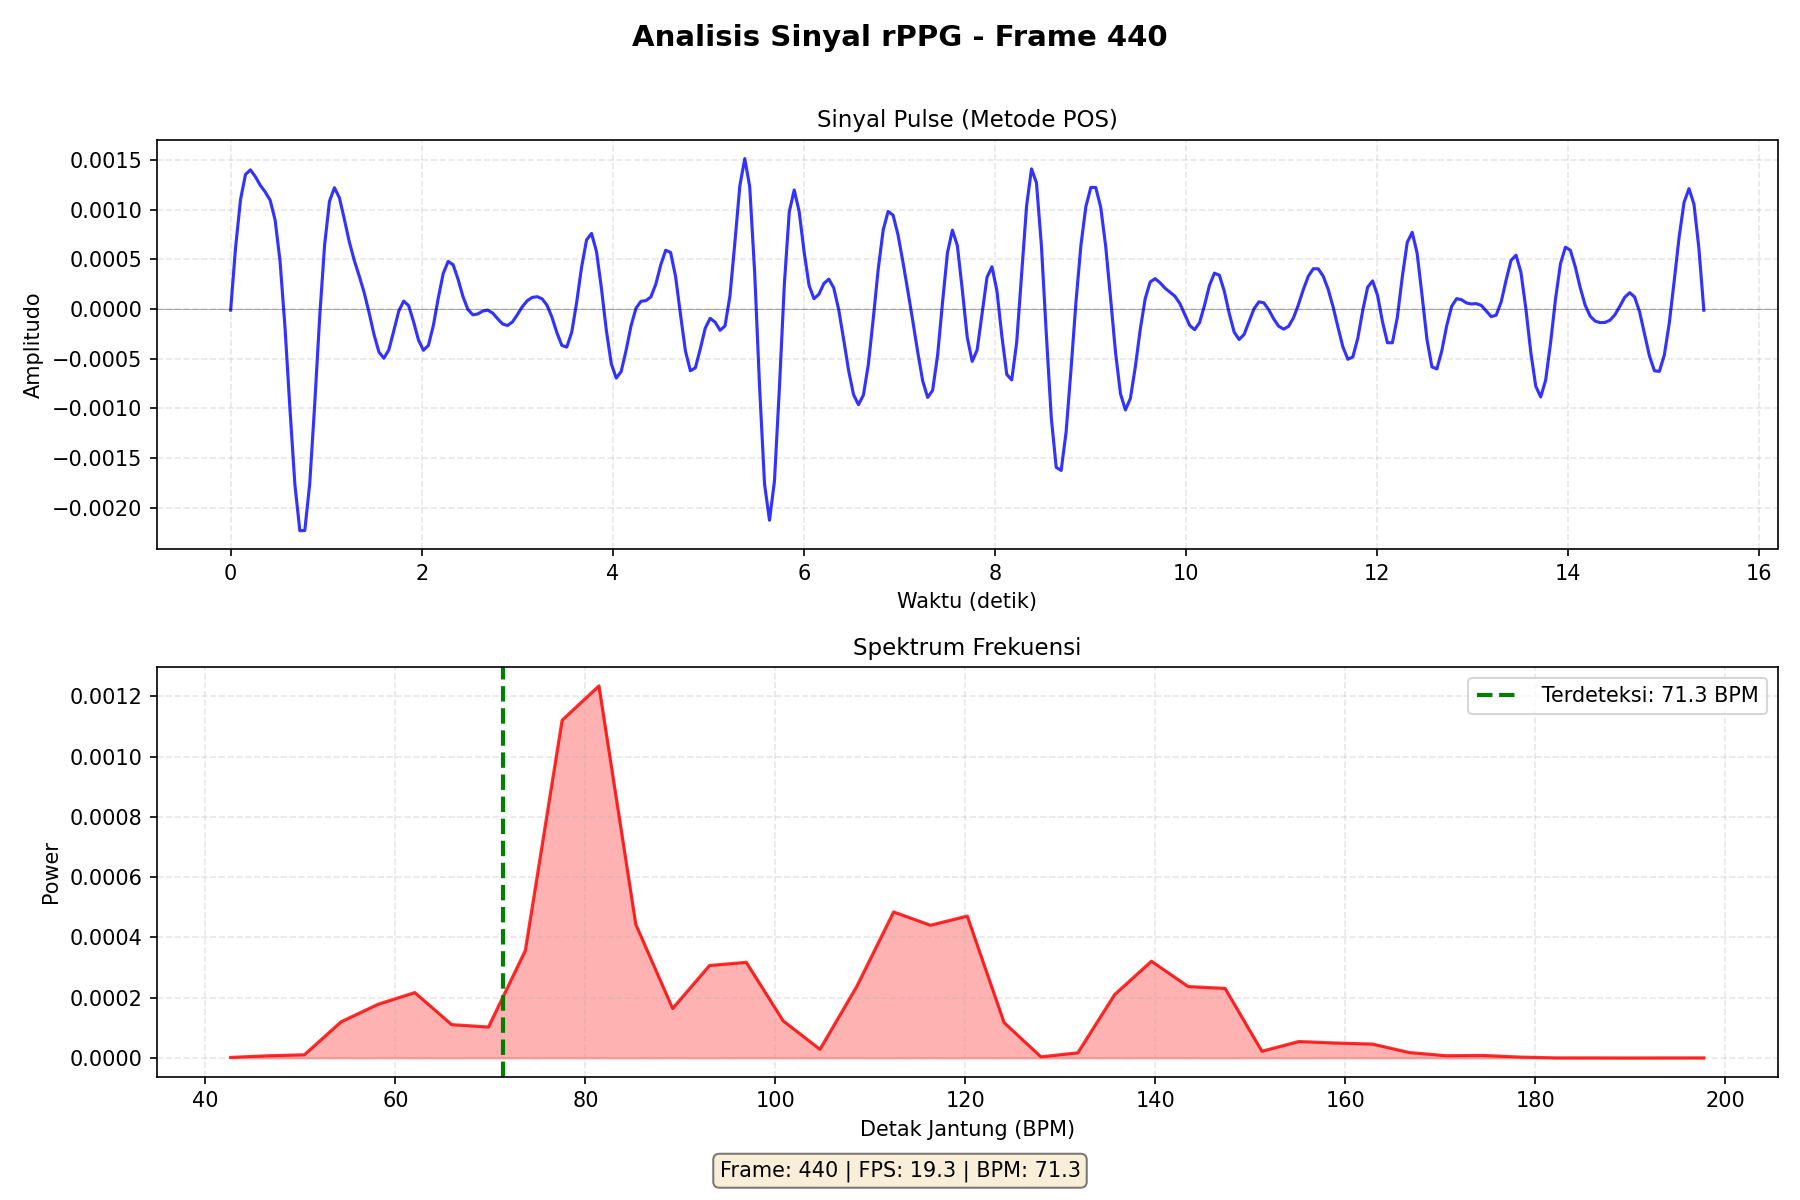

Menampilkan screenshot terbaru: screenshot_1764715782.png


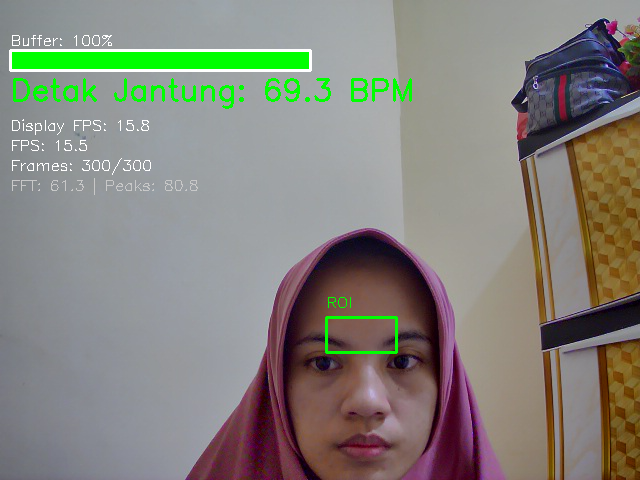

In [9]:
# Tampilkan gambar plot
try:
    from IPython.display import Image, display
    display(Image('rppg_plot_latest.png'))
except Exception as e:
    print('Plot terbaru belum tersedia atau gagal ditampilkan:', e)

# Opsional: tampilkan screenshot terbaru jika ada
import glob, os
screenshots = sorted(glob.glob('screenshot_*.png'))
if screenshots:
    latest_ss = screenshots[-1]
    print('Menampilkan screenshot terbaru:', latest_ss)
    try:
        display(Image(latest_ss))
    except Exception as e:
        print('Gagal menampilkan screenshot:', e)
else:
    print('Belum ada file screenshot_*.png')

## 7. Penjelasan Metode - Teori di Balik rPPG
---

### 7.1 Metode POS (Plane-Orthogonal-to-Skin)

**Konsep:**
Metode untuk ekstraksi sinyal pulse dari nilai RGB yang lebih robust terhadap perubahan pencahayaan.

**Alasan penggunaan**
- Lebih tahan terhadap perubahan pencahayaan ambient
- Mengurangi pengaruh gerakan kepala
- Channel hijau (G) paling sensitif terhadap perubahan darah

---

### 7.2 Bandpass Filter

**Tujuan:**
Filter frekuensi untuk **hanya loloskan** sinyal detak jantung (50-150 BPM) dan **buang** noise di luar range.

**Spesifikasi:**
- **Type**: Butterworth bandpass filter
- **Order**: 4 (trade-off antara kecuraman & stabilitas)
- **Low cutoff**: 0.83 Hz = 50 BPM (detak paling lambat)
- **High cutoff**: 2.5 Hz = 150 BPM (detak paling cepat)

**Kenapa range ini?**
- Detak jantung normal manusia: 60-100 BPM (istirahat)
- Detak saat aktivitas ringan: 100-150 BPM
- Di bawah 50 BPM = kemungkinan bukan detak jantung
- Di atas 150 BPM = kemungkinan noise
---

### 7.3 Estimasi BPM dengan FFT

**FFT (Fast Fourier Transform):**
Mengubah sinyal dari domain waktu → domain frekuensi untuk menemukan frekuensi dominan.

**Langkah-langkah:**

1. **Windowing**: Hamming window untuk kurangi spectral leakage
2. **FFT**: Transform ke domain frekuensi
3. **Cari Puncak**: Frekuensi dengan power tertinggi
4. **Interpolasi Parabola**: Untuk akurasi sub-bin
   - Pakai 3 titik: sebelum, puncak, sesudah
   - Fit parabola → cari puncak sebenarnya
   - Meningkatkan akurasi dari ±1 BPM menjadi ±0.1 BPM

**Output:** Frekuensi dalam Hz → dikali 60 → BPM

---

### 7.4 Estimasi BPM dengan Peak Detection

**Konsep:**
Deteksi puncak sinyal pulse di domain waktu, lalu hitung interval antar puncak.

**Langkah-langkah:**

1. **Find Peaks**: Deteksi puncak dengan kriteria:
   - `distance`: Minimal 0.5 detik antar puncak
   - `prominence`: Minimal 30% std deviasi 
2. **Hitung Interval**
3. **Konversi ke BPM**
---

### 7.5 Kombinasi FFT + Peak Detection

**Alasan penggunaan**
- **FFT**: Akurat untuk sinyal bersih, tapi sensitif terhadap noise
- **Peak Detection**: Robust terhadap noise, tapi kurang akurat